# **Step2. Multi-label 분류**



**미션 : 리뷰에 포함된 11가지 속성을 검출하기(Multi-label Multi-Classification)**

1) 목표 : 리뷰 내용에서, 속성에 해당하는 내용이 등장하는지 분류하는
모델 생성
2) 절차
    * 데이터 전처리 : 주어진 데이터를 목표에 맞는 형태로 변환
    * 모델링 : 다중 레이블 분류 파인 튜닝
        * 일반 파인 튜닝
        * LoRA 파인 튜닝

## 1.환경준비

### (1) 라이브러리 설치 및 로딩

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import torch

from transformers import Trainer, TrainingArguments, EarlyStoppingCallback, AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import LabelEncoder

from peft import get_peft_model, LoraConfig, TaskType

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

In [3]:
# (Jupyter) 시각화 한글폰트 설정을 위해 아래 코드를 실행하세요.
plt.rc('font', family='Malgun Gothic')
sns.set(font="Malgun Gothic",#"NanumGothicCoding",
        rc={"axes.unicode_minus":False}, # 마이너스 부호 깨짐 현상 해결
        style='darkgrid')

### (2) GPU 설정
* GPU 사용을 위한 설정

In [4]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 2.데이터 준비

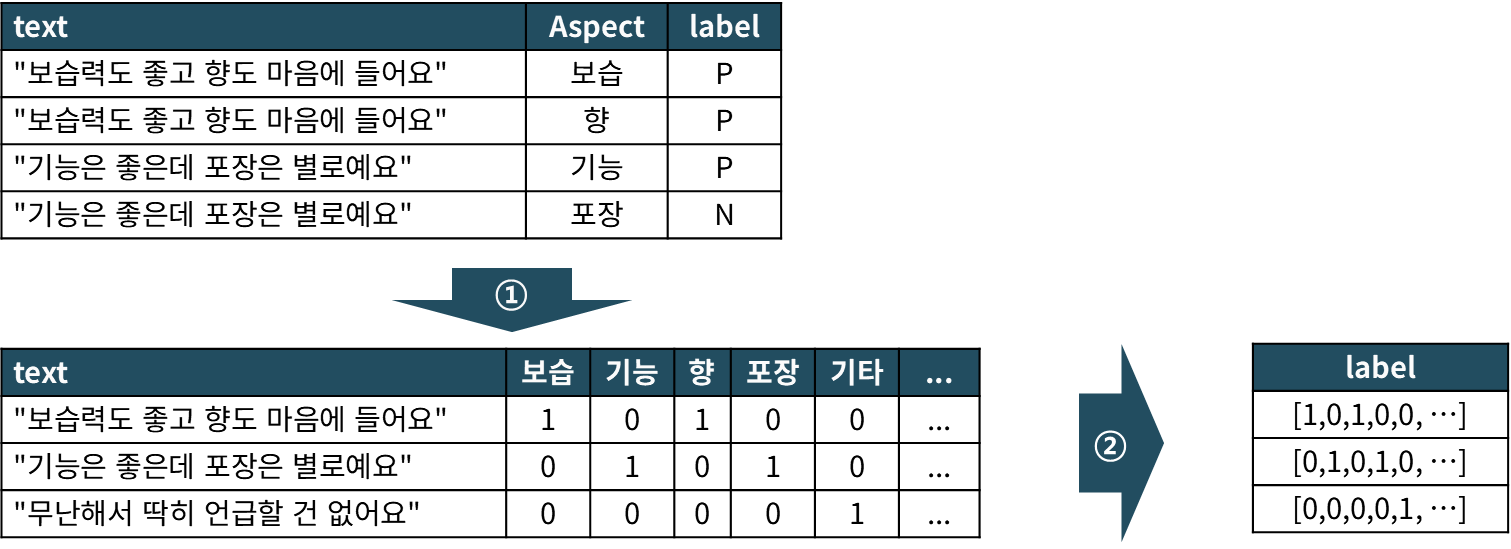

### (1) 데이터 로딩
* data.csv 파일 로딩

In [5]:
path = './data/'
df = pd.read_csv(path + 'data.csv')

### (2) Dataset 준비1

In [6]:
# 레이블 리스트
labels = ['보습', '기능', '밀착', '가격', '향', '편의성', '기타', '외형', '포장', '품질', '피부']

* multi-hot label 만들기
    * multi-hot label 값이 문자열이 아닌 리스트여야 합니다.
* multi-hot label을 추가한 데이터셋을 data1 으로 저장합니다.

In [7]:
df_drop = df.drop(columns=['label'])

In [8]:
review = "'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기로 워낙 유명한 토너죠~ OO 명예의 전당에 오른 것도 놀랍지 않네요^^ 무색무취의 물 같은 제형으로 그냥 손바닥에만 덜어 봐도 무자극이란 느낌이 딱 와요. 그렇다고 단순히 닦아내 주기만 하는 게 아니라 피부에 부드럽게 흡수되면서 가벼운 보습감이 오래 지속된답니다. 500ml 대용량인데 손바닥에 덜기 불편한 용기라서 그 점만 좀 개선해 주면 더 좋겠어요. 피부 예민한 분들께 인생템이 되어줄 수 있는 제품으로 추천해 드려요^^"
df[df['text'].str.startswith(review)]

,text,aspect,label
75381,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,보습,1
75382,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,품질,1
75383,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,포장,0
75384,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,포장,1
75385,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,피부,1
75386,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,기타,1
75387,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,밀착,1


In [9]:
# text와 aspect 컬럼 기준으로 중복 제거
df_unique = df.drop_duplicates(subset=['text', 'aspect']).reset_index(drop=True)

In [10]:
review = "'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기로 워낙 유명한 토너죠~ OO 명예의 전당에 오른 것도 놀랍지 않네요^^ 무색무취의 물 같은 제형으로 그냥 손바닥에만 덜어 봐도 무자극이란 느낌이 딱 와요. 그렇다고 단순히 닦아내 주기만 하는 게 아니라 피부에 부드럽게 흡수되면서 가벼운 보습감이 오래 지속된답니다. 500ml 대용량인데 손바닥에 덜기 불편한 용기라서 그 점만 좀 개선해 주면 더 좋겠어요. 피부 예민한 분들께 인생템이 되어줄 수 있는 제품으로 추천해 드려요^^"
df_unique[df_unique['text'].str.startswith(review)]

,text,aspect,label
74389,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,보습,1
74390,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,품질,1
74391,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,포장,0
74392,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,피부,1
74393,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,기타,1
74394,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,밀착,1


In [11]:
from sklearn.preprocessing import MultiLabelBinarizer

data = df_unique.groupby('text')['aspect'].apply(list).reset_index()
data.head(1)

,text,aspect
0,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,"[보습, 품질, 포장, 피부, 기타, 밀착]"


In [12]:
mlb = MultiLabelBinarizer(classes=labels)
multi_hot_array = mlb.fit_transform(data['aspect'])
data['label'] = [list(row) for row in multi_hot_array]
data.drop(columns=['aspect'], inplace=True)
data.head(3)
# ['보습', '기능', '밀착', '가격', '향', '편의성', '기타', '외형', '포장', '품질', '피부']

,text,label
0,'2021 OO 명예의 전당'에 오른 OOO OOOO 토너 사용후기예요. 성분 좋기...,"[1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1]"
1,'2022 대한민국소비자대상' 수상을 축하하며 오랜만에 써 본 OO OOO 로션 사...,"[1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1]"
2,'OO OOO 쿠션 파운데이션' 이 제품 이름을 보고 너무 궁금해서 구입했어요. 얼...,"[1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0]"


* 검증 : 제대로 생성되었는지 다음 코드로 검증해 봅니다.

In [13]:
review = "(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점)"
display(data[data['text'].str.startswith(review)])
display(df[df['text'].str.startswith(review)])

,text,label
3,(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점) 1.교체...,"[0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0]"


,text,aspect,label
42656,(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점) 1.교체...,밀착,1
42657,(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점) 1.교체...,품질,0
42658,(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점) 1.교체...,기타,1
42659,(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점) 1.교체...,편의성,1
42660,(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점) 1.교체...,향,1


* 전체 데이터에서 10000건을 샘플링 합니다.(파인튜닝 시간 절약을 위해서)

In [14]:
# 데이터 샘플링
size = 10000
df_10k = data[:size]

### (3) Dataset 준비2
* train, val 분할 7:3
* 텐서 데이터셋

In [15]:
# train, val 분할 7:3
from sklearn.model_selection import train_test_split

train, val = train_test_split(df_10k, test_size=0.3, random_state=42)

In [16]:
# df로 부터 텐서 데이터셋 만들기
train_ts = Dataset.from_pandas(train) 
val_ts = Dataset.from_pandas(val)

In [17]:
train_ts[:1]

{'text': ['도착하자마자 바로 사용했어요. 투명해지는데는 좀 오래 걸려요. 시원하고 피부가 쫀쫀해지는 느낌은 좋습니다. 선호하는 향은 아니지만 1일1 팩할 듯합니다. 가격은 더 저렴해지면 좋을 것 같아요.'],
 'label': [[1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0]],
 '__index_level_0__': [9069]}

### (4) 토크나이징

* 다중 레이블 분류 문제에서 label은 float 타입이어야 함

In [ ]:
# 토크나이저 다운로드
model_name = "klue/bert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
# 전처리 함수 정의 : label을 float 타입으로 변환 포함
max_length_overall = 0
max_text_overall = ""

def preprocess_function(examples):
    global max_length_overall, max_text_overall
    
    encodings = tokenizer(
        examples['text'],
        truncation=True,
        padding='max_length',
        max_length=128
    )
    
    # labels float 변환
    encodings['label'] = [list(map(float, l)) for l in examples['label']]
    
    # 각 배치에서 가장 긴 문장 확인
    for text in examples['text']:
        tokens_no_trunc = tokenizer(text, truncation=False)['input_ids']
        if len(tokens_no_trunc) > max_length_overall:
            max_length_overall = len(tokens_no_trunc)
            max_text_overall = text
    
    return encodings


# 전처리 적용
train_ts = train_ts.map(preprocess_function, batched=True)
val_ts = val_ts.map(preprocess_function, batched=True)

# 학습 후 가장 긴 문장 출력
print(f"배치 전체에서 가장 긴 문장({max_length_overall} 토큰) 잘림:\n{max_text_overall}")

Map: 100%|██████████| 3000/3000 [00:00<00:00, 3504.10 examples/s]

배치 전체에서 가장 긴 문장(564 토큰) 잘림:
남자친구가 이번에 스킨 로션이 필요한데 추천 좀 해달라고 해서 뭘 선물해줄까 고민하다가 올인원 제품을 선택했어요! 저희 남자친구가 귀차니즘이 심한데다가 겨울이라 보습력있고 자극없는 제품을 찾았습니다. 제 남자친구는 일이 바쁘고 꼼꼼하게 바르는 성격은 더욱 더 아니라 묽은 제형의 올인원을 택했습니다. 먼저 향은 목욕탕 스킨냄새까지는 아니어도 조금 아쉽다는 느낌이 들었지만 그래도 후레쉬한 향이라는 느낌이 들었습니다. 제형이 묽은 유형이라 발림성은 좋고 세안하고 아무렇게나 발라도 자극이 없어서 좋다고 합니다. 펌핑해서 쓰는 거라 양 조절하기 힘든 사람에게도 제격인 거 같아요. 제가 손에 해보니 흡수성이 빠른 편은 아니라 골고루 펴바른 뒤 손가락이나 손바닥으로 몇번 탁탁 두드리면 더 잘 흡수가 되더라고요. 남친도 해줬는데 앞으로 할까 모르겠네요. 피부좋은 남자가 되고 싶으시면 올인원 제품을 쓰면서 마스크팩을 일주일에 두세번 해주면 엄청 도움이 될 것 같아요! 생각난 김에 오늘 남친 마스크팩 좀 해줘야겠어요~ 두꺼운 턱수염으로 고생 꽤나 하는 일인입니다. 하루만 면도 안해도 콩나물처럼 무럭무럭 자라나고요. 귀찮지만 매일 해야되는데 피부는 예민해서 괜찮은 제품을 매번 찾아다닙니다. 그러던 중 OO 쉐이빙폼 제품을 친구에게 추천받았어요. 쉐이빙폼은 사용 전에 충분히 흔든 뒤 펌핑 한 후 나온 거품으로 면도할 부위를 고르 펴 바른 후 면도를 하는 제품입니다. 쉐이빙젤도 좋다고 하던데 저는 간편하고 풍성한 거품도 나오고 해서 쉐이빙 폼을 더 선호하는 편입니다. OOO 쉐이빙 폼은 피부자극없이 편안한 면도가 가능한데요. 캐모마일 꽃 추출물에 무에탄올성분 그리고 향이 정말 부드러운 느낌의 향이 나요. 면도를 해도 입가가 붉어지지 않고요. 써보니 계속 사용해주고 싶은 제품이더라고요. 화끈거림 건조함 피부당김 베임 등으로부터 보호해준다는 느낌을 받았습니다. 제가 피부가 민감해서 그런가 면도할 때는 더 예민해지는데 정말 편안하게 면도할

In [46]:
# 전처리 함수 정의 : label을 float 타입으로 변환 포함
def preprocess_function(examples):
    # tokenizer 적용
    encodings = tokenizer(examples['text'], truncation=True, padding='max_length', max_length=128)
    # labels float 변환
    encodings['label'] = [list(map(float, l)) for l in examples['label']]
    return encodings

# 전처리 적용
train_ts = train_ts.map(preprocess_function, batched=True)
val_ts = val_ts.map(preprocess_function, batched=True)

Map: 100%|██████████| 3000/3000 [00:00<00:00, 12195.11 examples/s]


## 3.Fine-Tuning1
* 일반 파인 튜닝으로

### (1) 사전학습 모델 준비
* problem_type="multi_label_classification"

In [49]:
# label(클래스) 수 지정
n = len(labels)

# 모델 준비 : 옵션 problem_type="multi_label_classification" 추가
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels = n,
    problem_type="multi_label_classification"
).to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### (2) 학습 설정

* TrainArguments

In [50]:
training_args = TrainingArguments(
    output_dir = './results',
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 2e-5,               # 작은 학습률
    per_device_train_batch_size = 32,   # 학습 배치 사이즈
    per_device_eval_batch_size = 32,
    num_train_epochs = 5,               # 에폭 수
    weight_decay = 0.02,                # weight decay
    load_best_model_at_end = True,      # earlystopping 사용하기 위해 필요
    logging_dir ='./logs',
    logging_steps = 10,
    report_to=None,
    fp16=True
)

* Trainer

In [51]:
# 학습 시 추가 함수 준비
from torch.utils.data import DataLoader
from transformers import default_data_collator

# 평가함수(선택 사항)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))  # sigmoid
    preds = (probs > 0.5).astype(int)
    return {
        "weighted_f1": f1_score(labels, preds, average="weighted"),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

# 사용자 정의 data_collator(필수 사항)
def float_label_collator(features):
    batch = default_data_collator(features)
    batch["labels"] = batch["labels"].float()
    return batch

In [52]:
# Trainer 설정 :
trainer = Trainer(
    model=model,                         # 학습할 모델
    args=training_args,                  # TrainingArguments
    train_dataset = train_ts,
    eval_dataset = val_ts,
    tokenizer = tokenizer,
    data_collator=float_label_collator,  # 필수사항
    compute_metrics=compute_metrics,     # 선택사항
)

C:\Users\USER\AppData\Local\Temp\ipykernel_19016\245137270.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


### (3) 학습
* 7000건 학습데이터에 대해서, 학습 시간이 10~13분 정도 소요 됩니다.

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Weighted F1,Macro F1
1,0.306300,0.277684,0.768072,0.748239
2,0.207900,0.209421,0.857178,0.856570
3,0.176600,0.183116,0.874782,0.873170
4,0.163600,0.171677,0.884774,0.883007
5,0.142900,0.167974,0.886100,0.883560


TrainOutput(global_step=1095, training_loss=0.22669816877199633, metrics={'train_runtime': 152.1651, 'train_samples_per_second': 230.013, 'train_steps_per_second': 7.196, 'total_flos': 2302407770880000.0, 'train_loss': 0.22669816877199633, 'epoch': 5.0})

### (4) 모델 검증평가

In [31]:
eval_results = trainer.evaluate()
print(f"Evaluation results: {eval_results}")

Evaluation results: {'eval_loss': 0.16475017368793488, 'eval_runtime': 4.294, 'eval_samples_per_second': 698.65, 'eval_steps_per_second': 43.782, 'epoch': 10.0}


* 예측값

In [68]:
pred_output = trainer.predict(val_ts)

In [ ]:
logits = pred_output.predictions    
label_ids = pred_output.label_ids

probs = 1 / (1 + np.exp(-logits))
preds = (probs > 0.5).astype(int)

sample_idx = 0 
pred_sample = preds[sample_idx]
predicted_classes = [labels[i] for i, v in enumerate(pred_sample) if v == 1]
print("예측값 (multi-hot vector):", pred_sample)
print("예측된 클래스:", predicted_classes)

예측값 (multi-hot vector): [1 0 1 0 0 0 0 0 0 0 0]
예측된 클래스: ['보습', '밀착']


* 실제값

In [73]:
true_sample = label_ids[sample_idx]
true_classes = [labels[i] for i, v in enumerate(true_sample) if v == 1]

print("실제값 (multi-hot vector):", true_sample)
print("실제 클래스:", true_classes)

실제값 (multi-hot vector): [1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
실제 클래스: ['보습', '밀착']


* 평가

In [75]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    label_ids,   
    preds,    
    average=None,
    zero_division=0
)

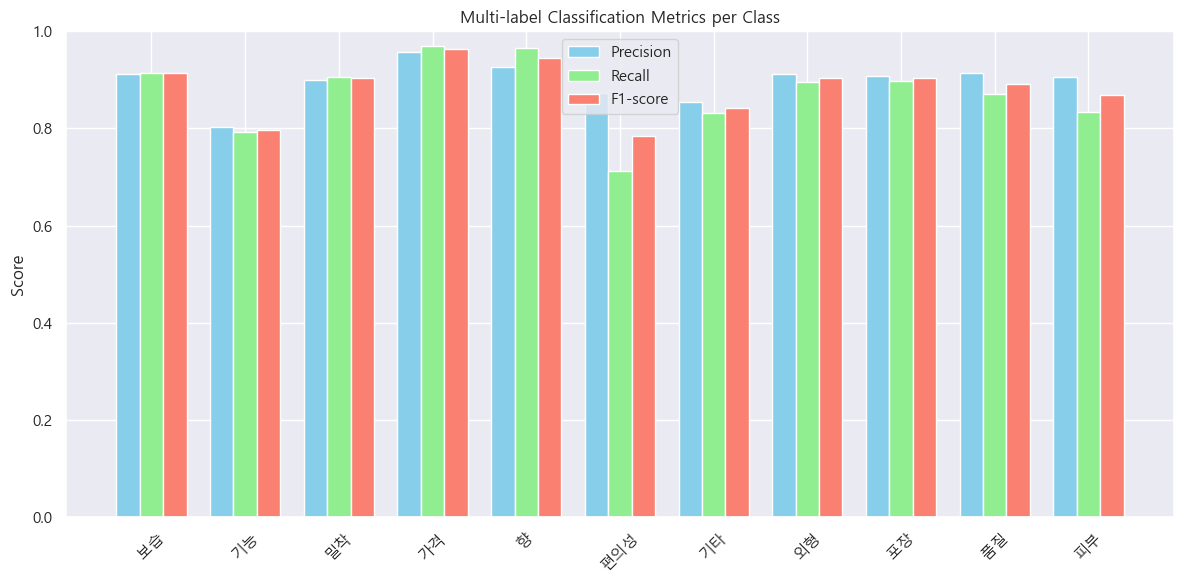

In [78]:
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(12,6))
plt.bar(x - width, precision, width, label='Precision', color='skyblue')
plt.bar(x, recall, width, label='Recall', color='lightgreen')
plt.bar(x + width, f1, width, label='F1-score', color='salmon')

plt.xticks(x, labels, rotation=45)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Multi-label Classification Metrics per Class')
plt.legend()
plt.tight_layout()
plt.show()


## 4.Fine-Tuning2
* LoRA 튜닝하기

### (1) 사전학습 모델 준비
* problem_type="multi_label_classification"

In [18]:
model_name = "klue/bert-base"
# label(클래스) 수 지정
n = len(labels)

# 모델 준비 : 옵션 problem_type="multi_label_classification" 추가
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels = n,
    problem_type="multi_label_classification"
).to(device)

tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess_function(examples):
    encodings = tokenizer(
        examples['text'],
        truncation=True,
        padding='max_length',
        max_length=128
    )
    encodings['labels'] = [list(map(float, l)) for l in examples['label']]
    return encodings

train_ts = train_ts.map(preprocess_function, batched=True)
val_ts = val_ts.map(preprocess_function, batched=True)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|██████████| 3000/3000 [00:00<00:00, 12499.95 examples/s]


### (2) LoRA 구성

In [ ]:
# LoRA 구성 정의
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, 
    r=8,                        
    lora_alpha=32,              
    lora_dropout=0.1,
    target_modules=["query", "value"],  
    bias="none"             
)

# LoRA 적용
model = get_peft_model(model, lora_config)

### (3) 학습 설정

* TrainArguments
    * 일반 파인 튜닝보다는 학습률을 조금 높게 설정

In [ ]:
training_args = TrainingArguments(
    output_dir = './results',
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 2e-4,        
    per_device_train_batch_size = 8,   # 학습 배치 사이즈
    per_device_eval_batch_size = 16,
    num_train_epochs = 5,               # 에폭 수
    weight_decay = 0.02,                # weight decay
    load_best_model_at_end = True,      # earlystopping 사용하기 위해 필요
    logging_dir ='./logs',
    logging_steps = 10,
    report_to=None,
    fp16=True
)

* Trainer

In [23]:
# 사용자 정의 data_collator 생
from torch.utils.data import DataLoader
from transformers import default_data_collator

def float_label_collator(features):
    batch = default_data_collator(features)
    batch["labels"] = batch["labels"].float()
    return batch

In [24]:
# Trainer 설정
trainer = Trainer(
    model=model,                         # 학습할 모델
    args=training_args,                  # TrainingArguments
    train_dataset = train_ts,
    eval_dataset = val_ts,
    tokenizer = tokenizer,
    data_collator=float_label_collator
)

C:\Users\USER\AppData\Local\Temp\ipykernel_3044\3448237408.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


### (4) 학습

In [25]:
# 학습 시작
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.276800,0.272543
2,0.223400,0.212999
3,0.162200,0.191630
4,0.201100,0.181024
5,0.178300,0.174233
6,0.177800,0.170319
7,0.102600,0.168973
8,0.107200,0.165805
9,0.135700,0.165293
10,0.114600,0.164750


TrainOutput(global_step=8750, training_loss=0.18264093589782715, metrics={'train_runtime': 500.8915, 'train_samples_per_second': 139.751, 'train_steps_per_second': 17.469, 'total_flos': 4621124766720000.0, 'train_loss': 0.18264093589782715, 'epoch': 10.0})

In [26]:
eval_results = trainer.evaluate()
print(f"Evaluation results: {eval_results}")

Evaluation results: {'eval_loss': 0.16475017368793488, 'eval_runtime': 4.14, 'eval_samples_per_second': 724.638, 'eval_steps_per_second': 45.411, 'epoch': 10.0}


### (5) 모델 검증평가

In [27]:
pred_output = trainer.predict(val_ts)
logits = pred_output.predictions    
label_ids = pred_output.label_ids

probs = 1 / (1 + np.exp(-logits))
preds = (probs > 0.5).astype(int)

sample_idx = 0 
pred_sample = preds[sample_idx]
predicted_classes = [labels[i] for i, v in enumerate(pred_sample) if v == 1]
print("예측값 (multi-hot vector):", pred_sample)
print("예측된 클래스:", predicted_classes)

예측값 (multi-hot vector): [1 0 1 0 0 0 0 0 0 0 0]
예측된 클래스: ['보습', '밀착']


In [28]:
true_sample = label_ids[sample_idx]
true_classes = [labels[i] for i, v in enumerate(true_sample) if v == 1]

print("실제값 (multi-hot vector):", true_sample)
print("실제 클래스:", true_classes)

실제값 (multi-hot vector): [1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
실제 클래스: ['보습', '밀착']


In [29]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    label_ids,   
    preds,    
    average=None,
    zero_division=0
)

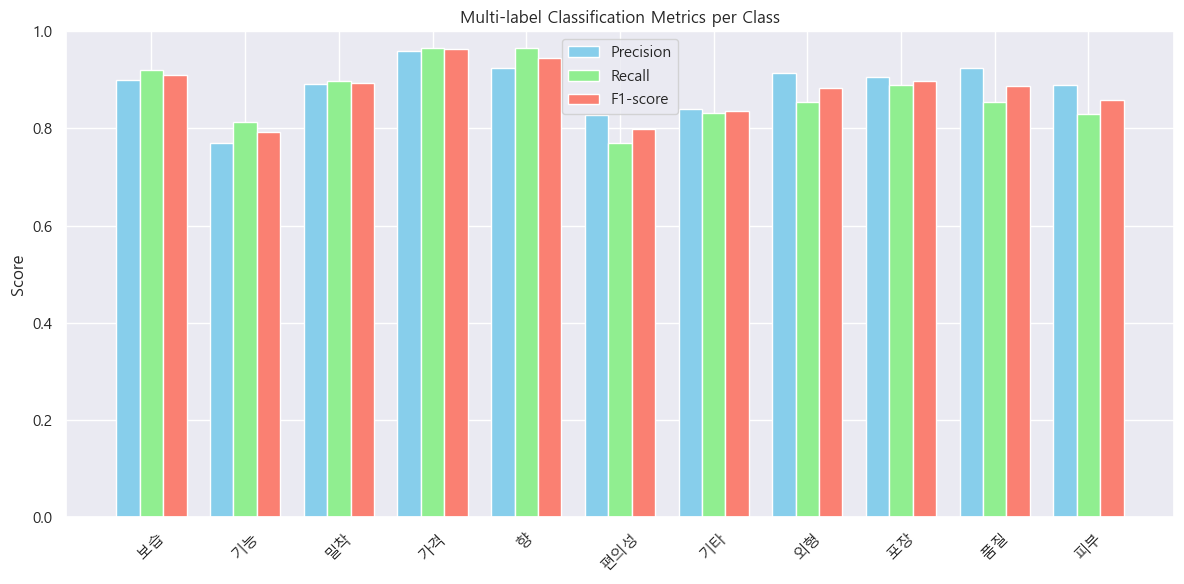

In [30]:
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(12,6))
plt.bar(x - width, precision, width, label='Precision', color='skyblue')
plt.bar(x, recall, width, label='Recall', color='lightgreen')
plt.bar(x + width, f1, width, label='F1-score', color='salmon')

plt.xticks(x, labels, rotation=45)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Multi-label Classification Metrics per Class')
plt.legend()
plt.tight_layout()
plt.show()
